In [2]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
)
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date    datetime64[us]
Temp           float64
dtype: object

In [4]:
print(df["Date"].min(), 
      df["Date"].max())
print(df["Date"].duplicated().sum())

1981-01-01 00:00:00 1990-12-31 00:00:00
0


In [5]:
gaps = df["Date"].diff()
print(gaps.value_counts())

Date
1 days    3647
2 days       2
Name: count, dtype: int64


In [6]:
print(df["Date"][gaps == pd.Timedelta("2 days")])

1460   1985-01-01
2920   1989-01-01
Name: Date, dtype: datetime64[us]


In [7]:
duplicated = df["Date"].duplicated()
print(duplicated.sum())

0


In [8]:
dup_mask = df["Date"].duplicated()
print(df.isna().sum())

Date    0
Temp    0
dtype: int64


In [9]:
print(df["Temp"].describe())


count    3650.000000
mean       11.177753
std         4.071837
min         0.000000
25%         8.300000
50%        11.000000
75%        14.000000
max        26.300000
Name: Temp, dtype: float64


<Axes: xlabel='Date'>

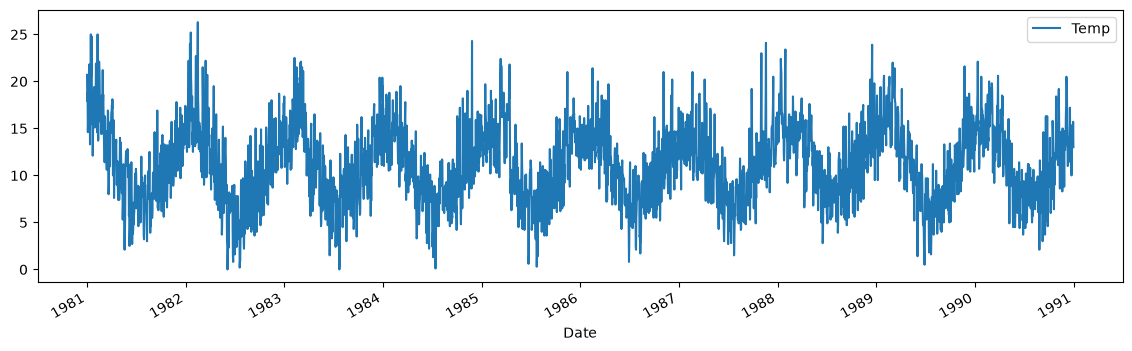

In [10]:
df.plot(x="Date", y="Temp", figsize=(14, 4))

In [11]:
df = df.set_index("Date")

In [12]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [13]:
df.index

DatetimeIndex(['1981-01-01', '1981-01-02', '1981-01-03', '1981-01-04',
               '1981-01-05', '1981-01-06', '1981-01-07', '1981-01-08',
               '1981-01-09', '1981-01-10',
               ...
               '1990-12-22', '1990-12-23', '1990-12-24', '1990-12-25',
               '1990-12-26', '1990-12-27', '1990-12-28', '1990-12-29',
               '1990-12-30', '1990-12-31'],
              dtype='datetime64[us]', name='Date', length=3650, freq=None)

In [14]:
df.loc["1985-06-16"]

Temp    7.7
Name: 1985-06-16 00:00:00, dtype: float64

In [15]:
df.resample("ME").mean()

,Temp
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323
...,...
1990-08-31,7.825806
1990-09-30,9.166667
1990-10-31,11.345161


In [16]:
df_full = df.asfreq("D")
print(df_full.shape)
print(df_full.isna().sum())

(3652, 1)
Temp    2
dtype: int64


In [17]:
df_full["is_imputed"] = df_full["Temp"].isna()

In [18]:
df_full["Temp"] = df_full["Temp"].interpolate(method="time")

In [19]:
print(df_full.loc["1984-12-29":"1985-01-02"])
print(df_full.isna().sum())

             Temp  is_imputed
Date                         
1984-12-29  16.00       False
1984-12-30  16.40       False
1984-12-31  14.85        True
1985-01-01  13.30       False
1985-01-02  15.20       False
Temp          0
is_imputed    0
dtype: int64


In [20]:
monthly = df_full.groupby(df_full.index.month)["Temp"]
print(monthly.agg(["mean", "std", "min", "max"]))

           mean       std  min   max
Date                                
1     15.030323  2.872859  8.5  25.2
2     15.373759  2.742785  9.2  26.3
3     14.565484  3.193744  7.4  22.4
4     12.088333  3.082299  5.7  21.8
5      9.866452  2.793387  2.1  16.5
6      7.278333  2.643746  0.0  13.0
7      6.692581  2.627618  0.0  13.0
8      7.891290  2.334022  1.7  14.3
9      8.976333  2.795901  3.0  19.2
10    10.309355  2.687778  4.7  18.4
11    12.479667  2.957246  5.7  24.3
12    13.856290  2.474217  8.2  23.9


In [21]:
actual = df_full["Temp"].resample("ME").mean()
print(actual.head(12))

Date
1981-01-31    17.712903
1981-02-28    17.678571
1981-03-31    13.500000
1981-04-30    12.356667
1981-05-31     9.490323
1981-06-30     7.306667
1981-07-31     7.577419
1981-08-31     7.238710
1981-09-30    10.143333
1981-10-31    10.087097
1981-11-30    11.890000
1981-12-31    13.680645
Freq: ME, Name: Temp, dtype: float64


In [22]:
ref = df_full.groupby(df_full.index.month)["Temp"].agg(["mean", "std"])

m = actual.index.month
z = (actual - ref["mean"][m].values) / ref["std"][m].values

Text(0, 0.5, 'انحرافات معيارية')

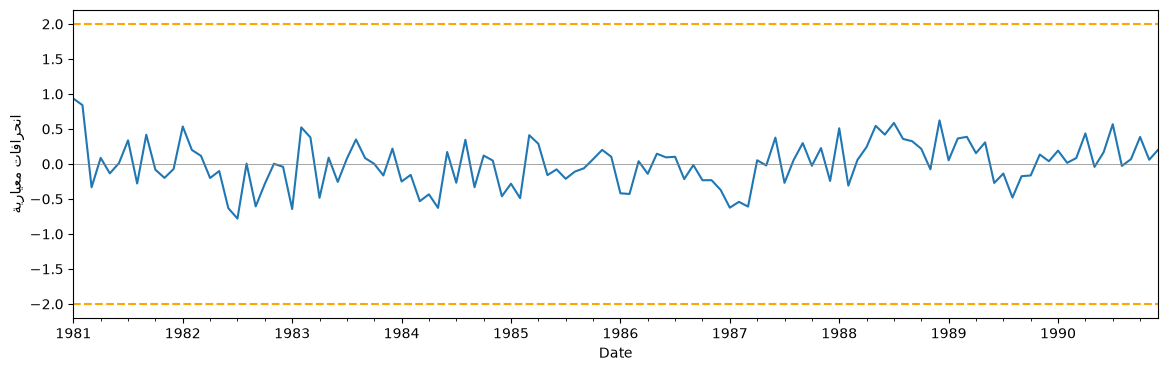

In [23]:
import matplotlib.pyplot as plt

z.plot(figsize=(14, 4))
plt.axhline(2, color="orange", linestyle="--")
plt.axhline(-2, color="orange", linestyle="--")
plt.axhline(0, color="gray", linewidth=0.5)
plt.ylabel("انحرافات معيارية")

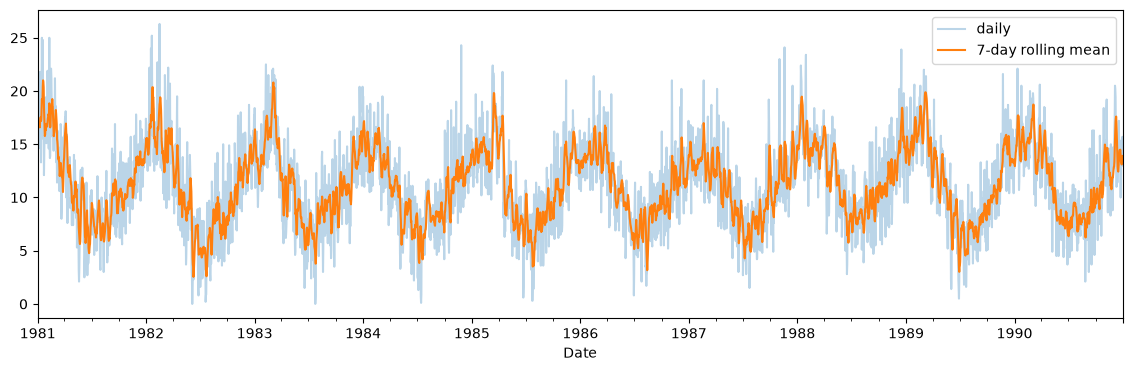

In [24]:
df_full["Temp"].plot(figsize=(14, 4), alpha=0.3, label="daily")
df_full["Temp"].rolling(7).mean().plot(label="7-day rolling mean")
plt.legend()

<Axes: xlabel='Date'>

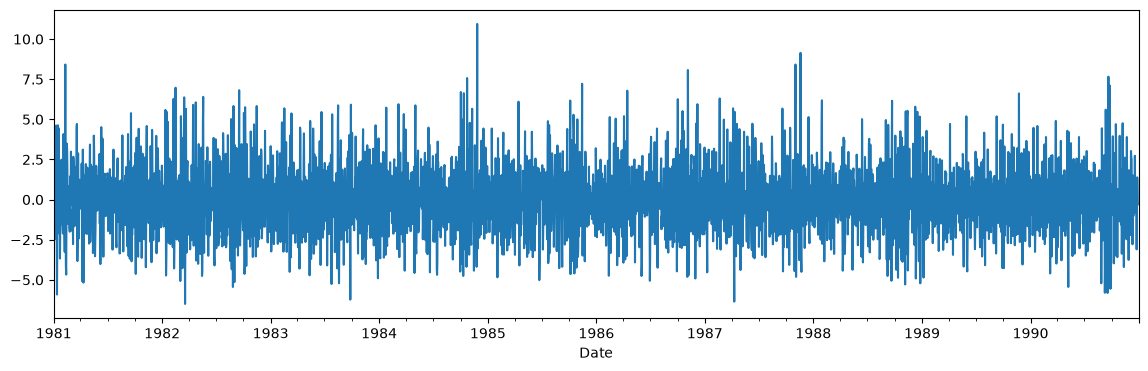

In [25]:
resid = df_full["Temp"] - df_full["Temp"].rolling(7, center=True).mean()
resid.plot(figsize=(14, 4))

<Axes: title={'center': 'Temp'}, xlabel='month'>

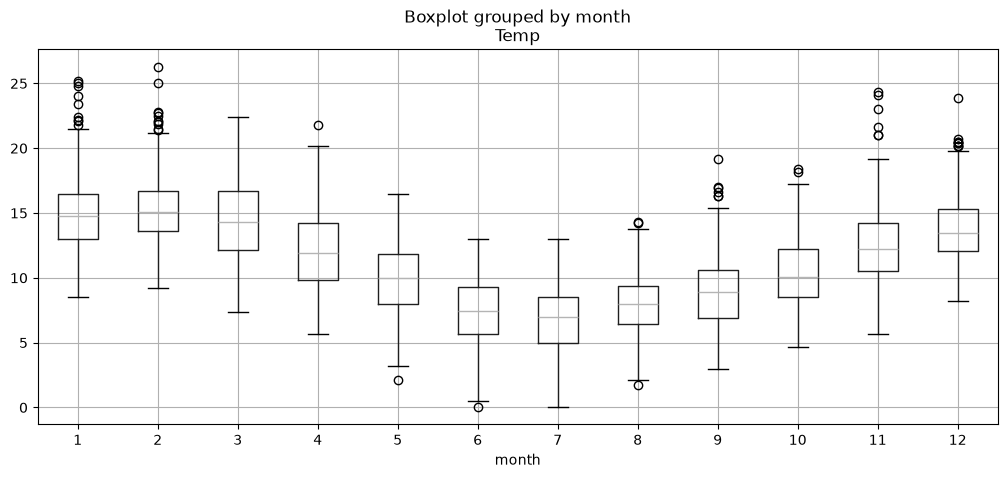

In [26]:
df_full["month"] = df_full.index.month
df_full.boxplot(column="Temp", by="month", figsize=(12, 5))

In [27]:
w = 7
feat = pd.DataFrame({
    "mean": df_full["Temp"].rolling(w).mean(),
    "std":  df_full["Temp"].rolling(w).std(),
    "max":  df_full["Temp"].rolling(w).max(),
    "min":  df_full["Temp"].rolling(w).min(),
})
feat["range"] = feat["max"] - feat["min"]
print(feat.tail())


                 mean       std   max   min  range
Date                                              
1990-12-27  13.100000  1.492202  14.6  10.0    4.6
1990-12-28  13.171429  1.504121  14.6  10.0    4.6
1990-12-29  13.214286  1.509336  14.6  10.0    4.6
1990-12-30  13.471429  1.775495  15.7  10.0    5.7
1990-12-31  13.900000  0.983192  15.7  12.9    2.8


In [28]:
feat["rms"] = df_full["Temp"].rolling(w).apply(lambda x: (x**2).mean()**0.5)
print(feat[["mean", "rms"]].tail())

                 mean        rms
Date                            
1990-12-27  13.100000  13.172645
1990-12-28  13.171429  13.244837
1990-12-29  13.214286  13.287964
1990-12-30  13.471429  13.571346
1990-12-31  13.900000  13.929773
